# CNN - GoogLeNet Inception V1 — Classificação Binária
## Adaptado para: Chest X-Ray (Pneumonia vs Normal)

---
### 📋 Resumo das Modificações Aplicadas ao Código Base

| # | O que foi alterado | Original | Novo valor | Justificativa |
|---|---|---|---|---|
| 1 | `kernel_size` (1ª Conv2D) | `(7, 7)` | `(3, 3)` | Imagens 32x32 são pequenas; kernel 7x7 cobre 22% da imagem e perde detalhes |
| 2 | `stride` (1ª Conv2D) | `(2, 2)` | `(1, 1)` | Stride 1 preserva mais informação espacial em imagens pequenas |
| 3 | `epochs` | `100` | `20` | Dataset de baixa variabilidade converge rápido; reduz tempo de GPU |
| 4 | Camada de saída principal | `Dense(10, activation='softmax')` | `Dense(1, activation='sigmoid')` | Classificação binária exige 1 neurônio + sigmoid |
| 5 | Camada de saída auxiliar | `Dense(10, activation='softmax')` | `Dense(1, activation='sigmoid')` | Mesma razão do item 4 |
| 6 | Função de perda | `categorical_crossentropy` | `binary_crossentropy` | Perda padrão para classificação binária |
| 7 | Carregamento de dados | `cifar10.load_data()` | `load_chestxray_data()` | Troca do dataset |
| 8 | Input shape | `(32, 32, 3)` | `(32, 32, 3)` | **Mantido** — imagens são redimensionadas para manter compatibilidade |

---
> **Tudo que NÃO está na tabela acima permanece idêntico ao código do professor.**

## ⚙️ Setup do Ambiente Kaggle

Antes de executar, certifique-se de que:
1. O dataset `chest-xray-pneumonia` está adicionado ao notebook em **Data → Add Data**
2. O accelerator está configurado como **GPU** em **Settings → Accelerator**

## Bibliotecas

In [1]:
# Importação das bibliotecas necessárias
# ✅ IDÊNTICO AO CÓDIGO BASE — nenhuma biblioteca foi adicionada ou removida
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, MaxPooling2D, Dropout, Dense, Input, concatenate, GlobalAveragePooling2D, AveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import LearningRateScheduler
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import requests
from PIL import Image
from io import BytesIO
import os
import glob

2026-05-05 11:25:29.040285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777980329.274288      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777980329.340820      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777980329.871907      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777980329.871947      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777980329.871950      23 computation_placer.cc:177] computation placer alr

In [2]:
# Verifica a quantidade de GPUs disponíveis
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


## Database

### 🔧 MODIFICAÇÃO 1/8 — Troca de Dataset

**Original:** `cifar10.load_data()` — dataset de 10 classes (avião, carro, pássaro...)

**Novo:** Chest X-Ray Pneumonia — dataset de **2 classes**: `NORMAL` (0) e `PNEUMONIA` (1)

**Por que este dataset?**
- Imagens altamente padronizadas (todas são radiografias frontais de tórax)
- Mesmo protocolo de captura → baixa variabilidade visual
- ~5.856 imagens com split train/test/val já pronto
- Dataset de referência acadêmica (Kermany et al., 2018)

**Kaggle slug:** `paultimothymooney/chest-xray-pneumonia`

In [3]:
def find_dataset_root(base='/kaggle/input/datasets/paultimothymooney'):
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            print(f"Dataset encontrado em: {root}")
            return root
    raise FileNotFoundError(f"Pastas 'train'/'test' não encontradas dentro de {base}")

def load_chestxray_data(img_rows, img_cols,
                        base_path='/kaggle/input/datasets/paultimothymooney'):
    real_path = find_dataset_root(base_path)

    def load_split(split_name):
        images, labels = [], []
        split_path = os.path.join(real_path, split_name)

        for label_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
            class_path = os.path.join(split_path, class_name)
            all_files = os.listdir(class_path)
            filepaths = [
                os.path.join(class_path, f)
                for f in all_files
                if f.lower().endswith(('.jpeg', '.jpg', '.png'))
            ]
            print(f'  [{split_name}] {class_name}: {len(filepaths)} imagens')

            for fp in filepaths:
                img = cv2.imread(fp)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_cols, img_rows))
                images.append(img)
                labels.append(label_idx)

        X = np.array(images, dtype='float32') / 255.0
        y = np.array(labels, dtype='float32').reshape(-1, 1)
        return X, y

    print('Carregando dados...')
    X_train, y_train = load_split('train')
    X_test,  y_test  = load_split('test')

    print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
    print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_chestxray_data(32, 32)
class_names = ['NORMAL', 'PNEUMONIA']

Dataset encontrado em: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Carregando dados...
  [train] NORMAL: 1341 imagens
  [train] PNEUMONIA: 3875 imagens
  [test] NORMAL: 234 imagens
  [test] PNEUMONIA: 390 imagens

X_train: (5216, 32, 32, 3) | y_train: (5216, 1)
X_test:  (624, 32, 32, 3)  | y_test:  (624, 1)


Distribuição no treino: NORMAL=1341 | PNEUMONIA=3875 | Total=5216
Proporção: 25.7% NORMAL | 74.3% PNEUMONIA


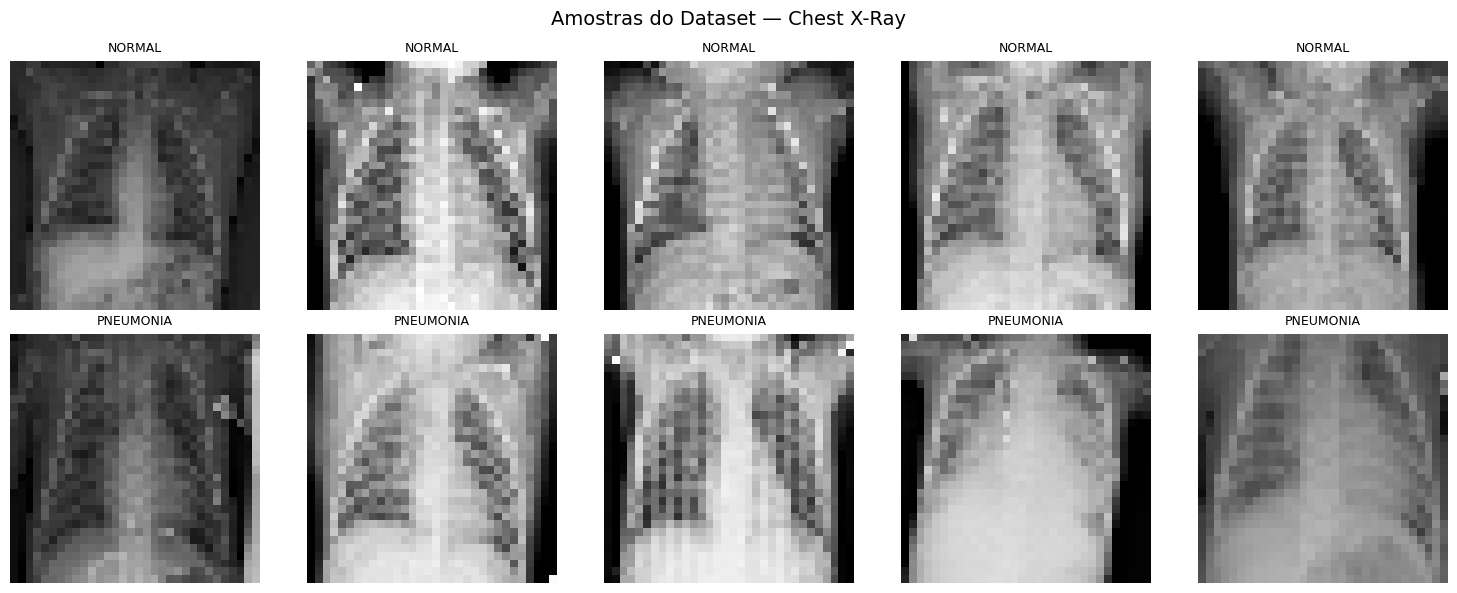

In [4]:
# Distribuição das classes — versão segura
n_normal    = int(np.sum(y_train == 0))
n_pneumonia = int(np.sum(y_train == 1))
total       = n_normal + n_pneumonia

print(f'Distribuição no treino: NORMAL={n_normal} | PNEUMONIA={n_pneumonia} | Total={total}')

if total > 0:
    print(f'Proporção: {n_normal/total:.1%} NORMAL | {n_pneumonia/total:.1%} PNEUMONIA')

    # Visualização de amostras
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Amostras do Dataset — Chest X-Ray', fontsize=14)

    for class_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
        indices = np.where(y_train.flatten() == class_idx)[0][:5]
        for col, idx in enumerate(indices):
            axes[class_idx, col].imshow(X_train[idx])
            axes[class_idx, col].set_title(class_name, fontsize=9)
            axes[class_idx, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem carregada. Verifique o caminho do dataset acima.")

## Inicializadores (idênticos ao código base)

In [5]:
# ✅ IDÊNTICO AO CÓDIGO BASE
kernel_init = tf.keras.initializers.GlorotUniform()
bias_init   = tf.keras.initializers.Constant(value=0.2)

## Inception Module (idêntico ao código base)

In [6]:
# ✅ IDÊNTICO AO CÓDIGO BASE — função inception_module sem alterações
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj, name=None):
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)

    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_3x3)

    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_5x5)

    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu',
                       kernel_initializer=kernel_init, bias_initializer=bias_init)(pool_proj)

    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3, name=name)
    return output

## Definição do Modelo de Inception

### 🔧 MODIFICAÇÕES 2 e 3/8 — kernel_size e stride

Aplicadas **somente na primeira camada convolucional** (`conv_1`), conforme escopo definido.

```
ANTES:  Conv2D(64, (7, 7), strides=(2, 2), ...)
DEPOIS: Conv2D(64, (3, 3), strides=(1, 1), ...)
```

**Impacto no shape intermediário:**
| Camada | Shape ANTES | Shape DEPOIS |
|---|---|---|
| Input | (32, 32, 3) | (32, 32, 3) |
| Conv 1 (kernel+stride) | (16, 16, 64) | **(32, 32, 64)** |
| MaxPool 1 | (8, 8, 64) | (16, 16, 64) |
| ... restante da rede ... | propaga redução | propaga redução |

In [7]:
# ✅ Input shape MANTIDO — (32, 32, 3) RGB
input_layer = Input(shape=(32, 32, 3))

In [8]:
# 🔧 MODIFICAÇÃO 2: kernel_size (7,7) → (3,3)
# 🔧 MODIFICAÇÃO 3: stride    (2,2) → (1,1)
# Razão: imagens 32x32 são pequenas — kernel 7x7 com stride 2 reduziria
# a resolução agressivamente logo na 1ª camada, descartando informação relevante.
# kernel 3x3 + stride 1 preserva mais detalhes espaciais.
x = Conv2D(64, (3, 3),          # 🔧 era (7, 7)
           padding='same',
           strides=(1, 1),      # 🔧 era (2, 2)
           activation='relu',
           name='conv_1_3x3div1',
           kernel_initializer=kernel_init,
           bias_initializer=bias_init)(input_layer)

I0000 00:00:1777980431.568824      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777980431.574836      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = MaxPooling2D((3, 3), padding='same', strides=(2, 2), name='max_pool_1_3x3div2')(x)

In [10]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = Conv2D(64, (1, 1), padding='same', activation='relu', name='conv_2a_3x3div1')(x)

In [11]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = Conv2D(192, (3, 3), padding='same', activation='relu', name='conv_2b_3x3div1')(x)

In [12]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = MaxPooling2D((3, 3), padding='same', strides=(2, 2), name='max_pool_2_3x3div2')(x)

## Módulos de Inception (x) — idênticos ao código base

In [13]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = inception_module(x, filters_1x1=64, filters_3x3_reduce=96, filters_3x3=128,
                     filters_5x5_reduce=16, filters_5x5=32, filters_pool_proj=32,
                     name='inception_3a')

In [14]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = inception_module(x, filters_1x1=128, filters_3x3_reduce=128, filters_3x3=192,
                     filters_5x5_reduce=32, filters_5x5=96, filters_pool_proj=64,
                     name='inception_3b')

In [15]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = MaxPooling2D((3, 3), padding='same', strides=(2, 2), name='max_pool_3_3x3div2')(x)

## Classificadores Auxiliares (x1)

### 🔧 MODIFICAÇÃO 5/8 — Saída Auxiliar: 10→1 neurônio, softmax→sigmoid

In [16]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x1 = AveragePooling2D((3, 3), strides=2, padding='same')(x)

In [17]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x1 = Conv2D(128, (1, 1), padding='same', activation='relu')(x1)

In [18]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x1 = Flatten()(x1)

In [19]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x1 = Dense(2048, activation='relu')(x1)

In [20]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x1 = Dropout(0.2)(x1)

In [21]:
# 🔧 MODIFICAÇÃO 5/8: Saída auxiliar adaptada para classificação binária
#
# ANTES:  Dense(10, activation='softmax', name='auxilliary_output_1')
# DEPOIS: Dense(1,  activation='sigmoid', name='auxilliary_output_1')
#
# Por que?
#   - Problema binário = 1 neurônio de saída
#   - sigmoid mapeia (-inf, +inf) → (0, 1) = probabilidade da classe POSITIVA (PNEUMONIA)
#   - softmax com 2 classes seria equivalente, mas sigmoid é a convenção para output binário
x1 = Dense(1, activation='sigmoid', name='auxilliary_output_1')(x1)  # 🔧 era Dense(10, 'softmax')

## Mais Módulos de Inception e Classificador Final

### 🔧 MODIFICAÇÃO 4/8 — Saída Principal: 10→1 neurônio, softmax→sigmoid

In [22]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = inception_module(x, filters_1x1=256, filters_3x3_reduce=160, filters_3x3=320,
                     filters_5x5_reduce=32, filters_5x5=128, filters_pool_proj=128,
                     name='inception_5a')

In [23]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = inception_module(x, filters_1x1=384, filters_3x3_reduce=192, filters_3x3=384,
                     filters_5x5_reduce=48, filters_5x5=128, filters_pool_proj=128,
                     name='inception_5b')

In [24]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = GlobalAveragePooling2D(name='avg_pool_5_3x3_1')(x)

In [25]:
# ✅ IDÊNTICO AO CÓDIGO BASE
x = Dropout(0.2)(x)

In [26]:
# 🔧 MODIFICAÇÃO 4/8: Saída principal adaptada para classificação binária
#
# ANTES:  Dense(10, activation='softmax', name='output')
# DEPOIS: Dense(1,  activation='sigmoid', name='output')
#
# Interpretação da saída:
#   pred < 0.5  →  NORMAL    (classe 0)
#   pred >= 0.5 →  PNEUMONIA (classe 1)
x = Dense(1, activation='sigmoid', name='output')(x)  # 🔧 era Dense(10, 'softmax')

## Criação do Modelo Final (idêntico ao código base)

In [27]:
# ✅ IDÊNTICO AO CÓDIGO BASE
model = Model(input_layer, [x, x1], name='inception_v1_binary')
model.summary()

Model: "inception_v1_binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_3x3div1      │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_1_3x3div2  │ (None, 16, 16,    │          0 │ conv_1_3x3div1[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2a_3x3div1     │ (None, 16, 16,    │      4,160 │ max_pool_1_3x3di… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2b_3x3div1     │ (None, 16, 16,    │    110,784 │ conv_2a_3x3div1[… │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_2_3x3div2  │ (None, 8, 8, 192) │          0 │ conv_2b_3x3div1[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 96)  │     18,528 │ max_pool_2_3x3di… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 16)  │      3,088 │ max_pool_2_3x3di… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 8, 192) │          0 │ max_pool_2_3x3di… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 64)  │     12,352 │ max_pool_2_3x3di… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │    110,720 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 32)  │     12,832 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 32)  │      6,176 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 8, 8, 256) │          0 │ conv2d[0][0],     │
│ (Concatenate)       │                   │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 32)  │      8,224 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 256) │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 192) │    221,376 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,069,218 (15.52 MB)

 Trainable params: 4,069,218 (15.52 MB)

 Non-trainable params: 0 (0.00 B)

## Parâmetros de Treinamento

### 🔧 MODIFICAÇÃO 3/8 — Epochs: 100 → 20

**Justificativa:** O dataset Chest X-Ray tem baixa variabilidade visual (imagens padronizadas). 
Com 20 épocas já é possível observar convergência e comparar resultados entre experimentos 
de forma eficiente, economizando tempo de GPU no Kaggle.

In [28]:
# 🔧 MODIFICAÇÃO 3/8: epochs 100 → 20
epochs = 20            # era 100
initial_lrate = 0.01   # ✅ IDÊNTICO AO CÓDIGO BASE

## Função de Decaimento da Taxa de Aprendizado (idêntica ao código base)

In [29]:
# ✅ IDÊNTICO AO CÓDIGO BASE
def decay(epoch):
    drop = 0.96
    epochs_drop = 5
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

## Configuração do Otimizador (idêntico ao código base — usando SGD)

In [30]:
# ✅ IDÊNTICO AO CÓDIGO BASE — SGD com momentum
# Você pode trocar por Adam ou RMSprop conforme o professor demonstrou
optim = SGD(learning_rate=initial_lrate, momentum=0.9, nesterov=False)

# Callback de decaimento
lr_sc = LearningRateScheduler(decay, verbose=1)

## Compilação do Modelo

### 🔧 MODIFICAÇÃO 6/8 — Loss: categorical_crossentropy → binary_crossentropy

```
ANTES:  loss=['categorical_crossentropy', 'categorical_crossentropy']
DEPOIS: loss=['binary_crossentropy',      'binary_crossentropy']
```

Tudo mais (`loss_weights`, `optimizer`, `metrics`) permanece idêntico ao código base.

In [31]:
model.compile(
    loss=['binary_crossentropy', 'binary_crossentropy'],  # 🔧 era 'categorical_crossentropy'
    loss_weights=[1, 0.3],                               # ✅ IDÊNTICO AO CÓDIGO BASE
    optimizer=optim,                                      # ✅ IDÊNTICO AO CÓDIGO BASE
    metrics=[['accuracy'], ['accuracy']]                  # ✅ IDÊNTICO AO CÓDIGO BASE
)

## Treinamento do Modelo (idêntico ao código base)

In [32]:
# ✅ IDÊNTICO AO CÓDIGO BASE — mesma estrutura de chamada com [y_train, y_train]
with tf.device('/gpu:0'):
    history = model.fit(
        X_train,
        [y_train, y_train],
        validation_data=(X_test, [y_test, y_test]),
        epochs=epochs,
        batch_size=512,
        callbacks=[lr_sc]
    )


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/20


I0000 00:00:1777980438.041905      72 service.cc:152] XLA service 0x7a224c0036a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777980438.041950      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777980438.041954      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777980438.941251      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/11 ━━━━━━━━━━━━━━━━━━━━ 3:56 24s/step - auxilliary_output_1_accuracy: 0.2637 - auxilliary_output_1_loss: 0.8195 - loss: 0.8392 - output_accuracy: 0.7363 - output_loss: 0.5933

I0000 00:00:1777980457.498225      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - auxilliary_output_1_accuracy: 0.5103 - auxilliary_output_1_loss: 0.6971 - loss: 0.7936 - output_accuracy: 0.7400 - output_loss: 0.5867 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.5609 - val_loss: 0.9081 - val_output_accuracy: 0.6250 - val_output_loss: 0.5642 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - auxilliary_output_1_accuracy: 0.7439 - auxilliary_output_1_loss: 0.5876 - loss: 0.7598 - output_accuracy: 0.7435 - output_loss: 0.5840 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.5648 - val_loss: 0.9085 - val_output_accuracy: 0.6250 - val_output_loss: 0.5342 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - auxilliary_output_1_accuracy: 0.7414 - auxilliary_output_1_loss: 0.5807 - loss: 0.7594 - outp

## Visualização do Treinamento

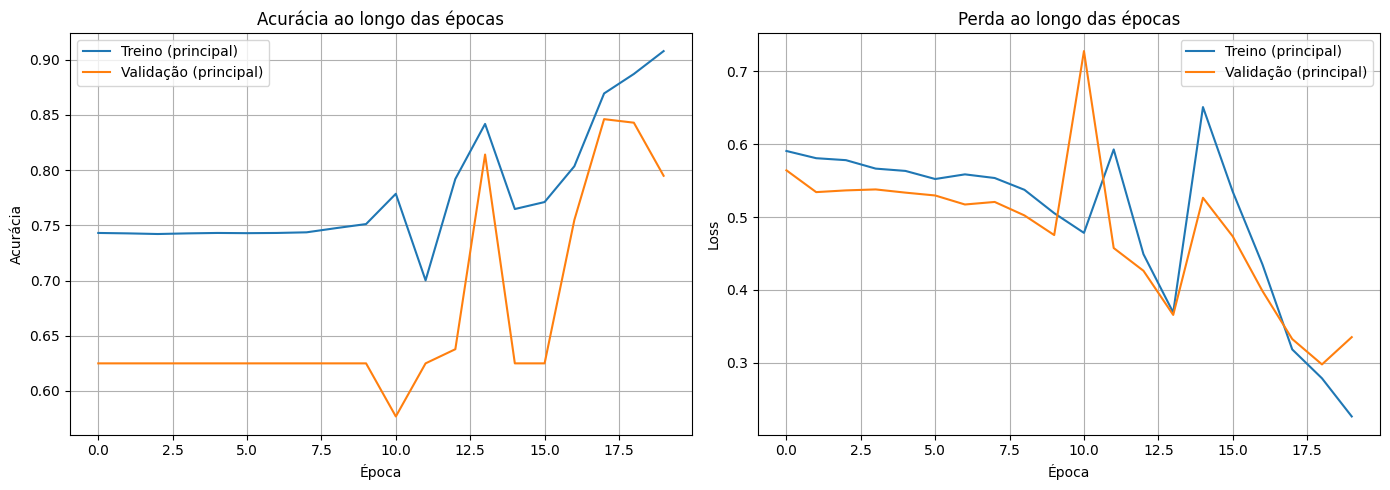

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(history.history['output_accuracy'],     label='Treino (principal)')
axes[0].plot(history.history['val_output_accuracy'], label='Validação (principal)')
axes[0].set_title('Acurácia ao longo das épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Perda
axes[1].plot(history.history['output_loss'],     label='Treino (principal)')
axes[1].plot(history.history['val_output_loss'], label='Validação (principal)')
axes[1].set_title('Perda ao longo das épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Avaliação e Predições

### 🔧 MODIFICAÇÃO 7e8/8 — Interpretação da saída: argmax → threshold (sigmoid)

Com sigmoid, a saída é um único valor em [0, 1]:
- `pred < 0.5` → NORMAL
- `pred >= 0.5` → PNEUMONIA

In [34]:
# Gera previsões — estrutura idêntica ao código base
predictions = model.predict(X_test)

# Separa as previsões principais e auxiliares — idêntico ao código base
main_predictions, aux1_predictions = predictions

# 🔧 MODIFICAÇÃO: sigmoid → threshold 0.5 (em vez de argmax usado no multiclasse)
# ANTES:  predicted_classes = np.argmax(main_predictions, axis=1)
# ANTES:  true_classes       = np.argmax(y_test, axis=1)
predicted_classes = (main_predictions >= 0.5).astype(int).flatten()
true_classes      = y_test.flatten().astype(int)

# Exibe resultados para os primeiros 5 exemplos do conjunto de teste
print('\n=== Primeiros 5 exemplos do conjunto de teste ===')
for i in range(5):
    prob = main_predictions[i][0]
    pred = class_names[predicted_classes[i]]
    true = class_names[true_classes[i]]
    status = '✅' if predicted_classes[i] == true_classes[i] else '❌'
    print(f'  [{i}] Predito: {pred:10s} | Real: {true:10s} | Prob: {prob:.4f} {status}')

# Acurácia global no teste
acc = np.mean(predicted_classes == true_classes)
print(f'\nAcurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)')

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step

=== Primeiros 5 exemplos do conjunto de teste ===
  [0] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.9629 ❌
  [1] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.8706 ❌
  [2] Predito: NORMAL     | Real: NORMAL     | Prob: 0.1969 ✅
  [3] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.9438 ❌
  [4] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.6305 ❌

Acurácia no conjunto de teste: 0.7949 (79.49%)


## Salvamento do Modelo

In [35]:
# Salva o modelo treinado
model.save('inception_v1_binary_chestxray.h5')
print('Modelo salvo: inception_v1_binary_chestxray.h5')

Modelo salvo: inception_v1_binary_chestxray.h5


## Predição em Imagens Individuais (via URL)

In [36]:
# URLs de exemplo — substitua por imagens de raio-X reais para testar
# Estrutura idêntica ao código base do professor
image_urls = [
    # Substitua pela URL de um raio-X normal
    'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg/800px-Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg',
]

def load_and_preprocess_image(url):
    """Idêntico ao código base do professor."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.resize((32, 32))
        img_array = image.img_to_array(img)
        
        # Garante 3 canais (grayscale → RGB)
        if img_array.shape[2] == 1:
            img_array = np.repeat(img_array, 3, axis=2)
        elif img_array.shape[2] == 4:  # RGBA → RGB
            img_array = img_array[:, :, :3]
        
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except Exception as e:
        print(f'Erro ao carregar imagem de {url}: {e}')
        return None


for url in image_urls:
    img_array = load_and_preprocess_image(url)
    if img_array is not None:
        predictions = model.predict(img_array)
        main_pred = predictions[0]  # saída principal
        prob = main_pred[0][0]
        # 🔧 MODIFICAÇÃO: threshold em vez de argmax
        predicted_class = class_names[int(prob >= 0.5)]
        print(f'URL: ...{url[-40:]}')
        print(f'  Predito: {predicted_class} | Probabilidade de PNEUMONIA: {prob:.4f}')
    else:
        print(f'Pulando imagem de {url} devido a erro de carregamento.')

Erro ao carregar imagem de https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg/800px-Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg: 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg/800px-Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg
Pulando imagem de https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg/800px-Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg devido a erro de carregamento.


---
## 📊 Resumo Final das Modificações

```
╔══════════════════════════════════════════════════════════════════════╗
║           MAPA DE MODIFICAÇÕES — Código Base → Binário              ║
╠══════════════════════════════════════════════════════════════════════╣
║ 1. kernel_size     │ (7,7)                  → (3,3)                 ║
║ 2. stride          │ (2,2)                  → (1,1)                 ║
║ 3. epochs          │ 100                    → 20                    ║
║ 4. output (main)   │ Dense(10, 'softmax')   → Dense(1, 'sigmoid')   ║
║ 5. output (aux)    │ Dense(10, 'softmax')   → Dense(1, 'sigmoid')   ║
║ 6. loss            │ categorical_crossentr. → binary_crossentropy   ║
║ 7. dataset         │ cifar10 (10 classes)   → chest-xray (2 classes)║
║ 8. argmax          │ np.argmax(pred, ax=1)  → (pred >= 0.5).astype  ║
╠══════════════════════════════════════════════════════════════════════╣
║ input_shape        │ (32, 32, 3)            → (32, 32, 3) MANTIDO   ║
║ inception_module() │ IDÊNTICO                                        ║
║ lr_schedule        │ IDÊNTICO                                        ║
║ loss_weights       │ [1, 0.3] IDÊNTICO                               ║
║ optimizer (SGD)    │ IDÊNTICO                                        ║
╚══════════════════════════════════════════════════════════════════════╝
```